### Validating the formula used by `calc_nft_mode_freqs()` against `sim_nft_waves()`

In [5]:
import matplotlib.pyplot as plt
import numpy as np

from neuromodes import EigenSolver
from neuromodes.io import fetch_example_surf
from neuromodes.waves import calc_nft_mode_freqs


In [6]:
seed = 0
nt = 200
t0 = 100
r = 50
gamma = 10
dt = 0.01

In [7]:
surf, medmask = fetch_example_surf(density='4k')
solver = EigenSolver(surf, medmask).solve(100)

In [8]:
ext_input = np.zeros((solver.n_verts, nt))
ext_input[:, :t0] = solver.emodes.sum(axis=1)[:, None]

In [9]:
waves = solver.decompose(solver.sim_nft_waves(ext_input=ext_input, r=r, gamma=gamma, dt=dt, method='ode'))

In [10]:
freqs = calc_nft_mode_freqs(solver.evals, r=r, gamma=gamma)
w = 2 * np.pi * freqs[:, None] * (np.arange(nt//2)) * dt
sines = np.concatenate([
    np.sin(w - np.pi/2)/50 + waves[:, [nt//2-1]],
    np.sin(w + np.pi/2)/50
], axis=1)

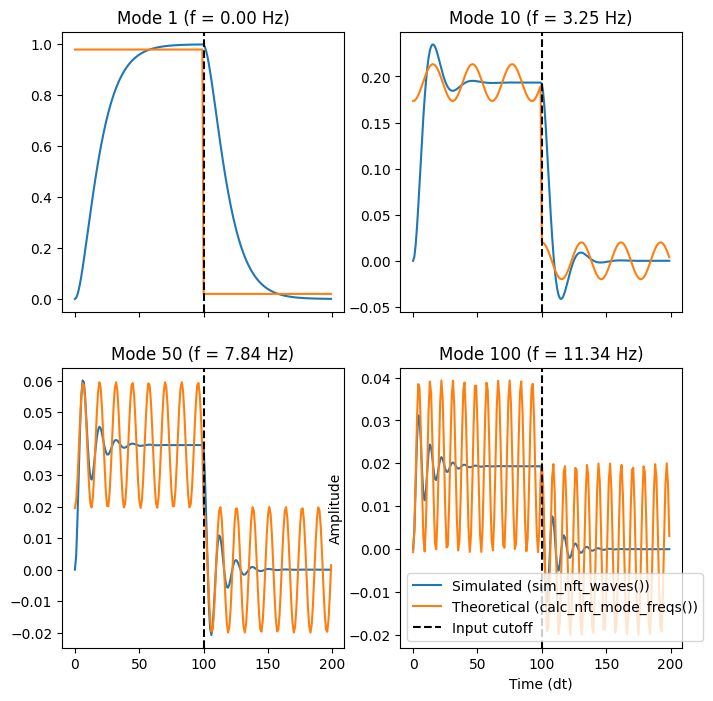

In [11]:
mode_inds = [0, 9, 49, 99]

fig, axs = plt.subplots(len(mode_inds)//2, 2, figsize=(8, 2*len(mode_inds)), sharex=True)
for i, idx in enumerate(mode_inds):
    row = i // 2
    col = i % 2
    axs[row, col].plot(waves[idx, :], label='Simulated (sim_nft_waves())')
    axs[row, col].plot(sines[idx, :], label='Theoretical (calc_nft_mode_freqs())')
    axs[row, col].axvline(x=t0, color='k', linestyle='--', label='Input cutoff')
    axs[row, col].set_title(f'Mode {idx+1} (f = {freqs[idx]:.2f} Hz)')
plt.xlabel('Time (dt)')
plt.ylabel('Amplitude')
plt.legend()
plt.show()